In [11]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
import pandas as pd

data = pd.read_excel('data-spell-checker.xlsx')

data.head()

,word,label
0,අභිචෝදකයා,1
1,අංකනය,1
2,අංකන,1
3,අංකය,1
4,අංකාන්තරය,1


In [13]:
# Extract features (X) and labels (y)
X = data['word'].tolist()
y = data['label'].values

In [14]:
# Convert labels to numpy array
y = np.array(y)

In [15]:
# Encode words (simple one-hot encoding for illustration)
vectorizer = CountVectorizer()
X_encoded = vectorizer.fit_transform(X).toarray()

In [16]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# neural network model
model = Sequential()
model.add(Dense(32, input_dim=X_encoded.shape[1], activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\nprav\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model and capture the history
history = model.fit(X_train, y_train, epochs=10, batch_size=1, verbose=1, validation_data=(X_test, y_test))

Epoch 1/10
81676/81676 ━━━━━━━━━━━━━━━━━━━━ 298s 4ms/step - accuracy: 0.7367 - loss: 0.5370 - val_accuracy: 0.7645 - val_loss: 0.5010
Epoch 2/10
81676/81676 ━━━━━━━━━━━━━━━━━━━━ 323s 4ms/step - accuracy: 0.7749 - loss: 0.4799 - val_accuracy: 0.7670 - val_loss: 0.4920
Epoch 3/10
81676/81676 ━━━━━━━━━━━━━━━━━━━━ 326s 4ms/step - accuracy: 0.7802 - loss: 0.4722 - val_accuracy: 0.7661 - val_loss: 0.4949
Epoch 4/10
81676/81676 ━━━━━━━━━━━━━━━━━━━━ 322s 4ms/step - accuracy: 0.7830 - loss: 0.4670 - val_accuracy: 0.7696 - val_loss: 0.4902
Epoch 5/10
81676/81676 ━━━━━━━━━━━━━━━━━━━━ 346s 4ms/step - accuracy: 0.7898 - loss: 0.4599 - val_accuracy: 0.7726 - val_loss: 0.4883
Epoch 6/10
81676/81676 ━━━━━━━━━━━━━━━━━━━━ 334s 4ms/step - accuracy: 0.7898 - loss: 0.4591 - val_accuracy: 0.7741 - val_loss: 0.4900
Epoch 7/10
81676/81676 ━━━━━━━━━━━━━━━━━━━━ 340s 4ms/step - accuracy: 0.7928 - loss: 0.4576 - val_accuracy: 0.7759 - val_loss: 0.4840
Epoch 8/10
81676/81676 ━━━━━━━━━━━━━━━━━━━━ 342s 4ms/step - ac

In [19]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

639/639 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7725 - loss: 0.4911
Test Accuracy: 77.78%


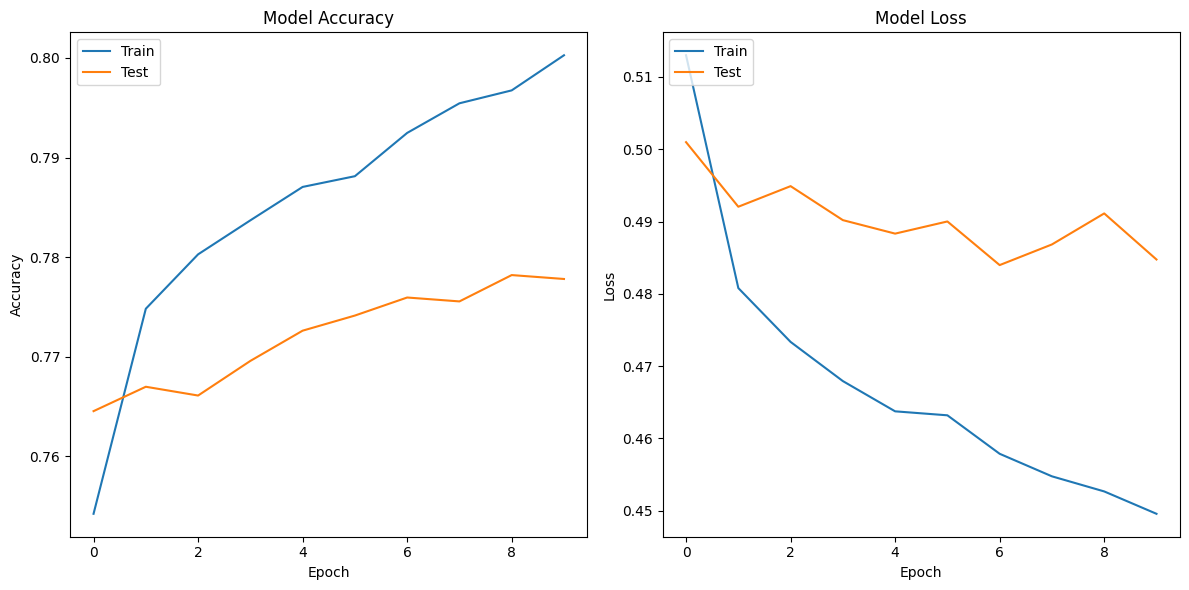

In [20]:
import matplotlib.pyplot as plt

# Plot training history
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()

In [41]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import joblib
from tensorflow.keras.models import save_model
import pickle

In [47]:
import tensorflow as tf

# Save the model using Keras's built-in method
model.save('best_sc_model.h5')

# Load the model later if needed
loaded_model = tf.keras.models.load_model('best_sc_model.h5')

In [ ]:
# Save the model as a pickle file
with open('best_sc_model.pkl', 'wb') as f:
    joblib.dump(model, f)
# Load the model from the pickle file
with open('best_sc_model.pkl', 'rb') as f:
    loaded_model_pkl = joblib.load(f)